# Lab: Simple Linear Regression

---

## 1. Introduction

In this notebook, we'll take the theory of Simple Linear Regression and apply it to a real-world dataset. We'll walk through the entire process, from loading and understanding the data to building, training, and evaluating our model.

*   **Goal:** To build a model that can predict the CO2 emissions of a car based on a single feature.
*   **Data:** Model-specific fuel consumption ratings and estimated CO2 emissions for new light-duty vehicles sold in Canada.

---

## 2. Setup and Data Loading

We'll begin by importing the essential Python libraries for data science: `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib` for plotting. Then, we'll load our dataset directly from a URL.

In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data directly from a URL into a Pandas DataFrame
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

# Get a quick, unbiased glimpse of the data
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
1023,2014,VOLKSWAGEN,BEETLE CONVERTIBLE,SUBCOMPACT,2.5,5,A6,X,11.2,8.7,10.1,28,232
944,2014,SUBARU,FORESTER AWD,SUV - SMALL,2.0,4,AV,Z,10.2,8.6,9.5,30,218
1052,2014,VOLKSWAGEN,TIGUAN,SUV - SMALL,2.0,4,M6,Z,13.6,9.2,11.6,24,267
90,2014,BMW,335i xDRIVE GRAN TURISMO,FULL-SIZE,3.0,6,A8,Z,11.9,8.0,10.1,28,232
257,2014,CHEVROLET,SONIC RS,COMPACT,1.4,4,AS6,X,9.4,7.0,8.3,34,191



---

## 3. Exploratory Data Analysis (EDA)

Before we can build a model, we need to understand our data. EDA helps us find patterns, spot outliers, and decide which features might be good predictors.

In [31]:
# The .describe() method gives a quick statistical summary of the numerical columns.
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


> **Observations:**
> - The `MODELYEAR` is 2014 for all cars, so this column won't be useful for prediction.  
> - The `FUELCONSUMPTION_COMB_MPG` has a maximum value of 60, which is significantly higher than the 75th percentile of 31. This could be a highly efficient hybrid car or a potential outlier.

Let's simplify our DataFrame to focus on a few potentially predictive features.

In [32]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
607,2.0,4,8.4,193
956,2.5,4,9.9,228
57,3.0,6,11.4,262
103,4.4,8,12.2,281
740,3.5,6,10.2,235


### Visualizing the Data
A picture is worth a thousand numbers. Let's create some plots to visually inspect the data:

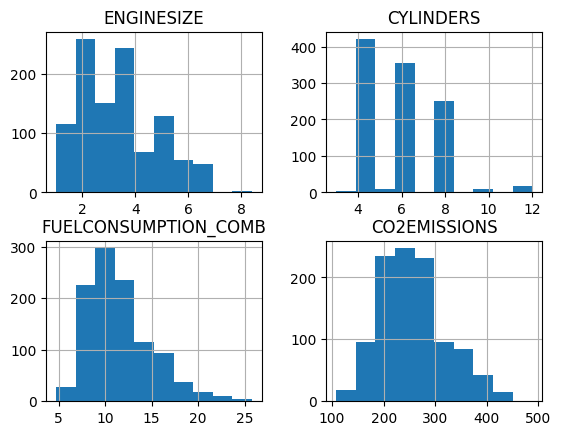

In [6]:
# Histograms help us see the distribution of each feature
cdf.hist()
plt.show()

> **Observations:**
> *   Most engines have 4, 6, or 8 cylinders.
> *   Most engine sizes are clustered between 2.0L and 4.0L.
> *   As we might expect, `FUELCONSUMPTION_COMB` and `CO2EMISSIONS` have similar right-skewed distributions.

Now, let's use scatter plots to check for linear relationships between our features and our target, `CO2EMISSIONS`.

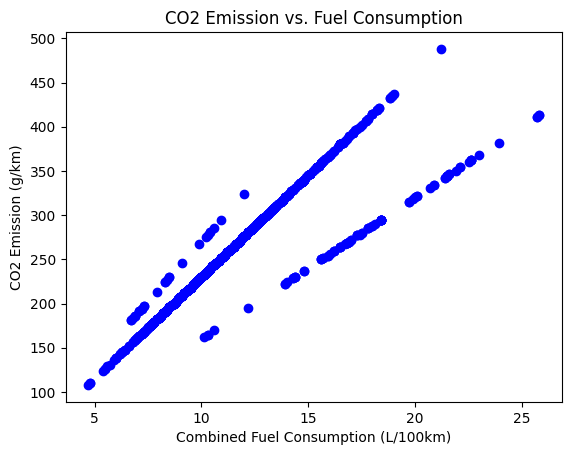

In [35]:
plt.scatter(cdf["FUELCONSUMPTION_COMB"], cdf["CO2EMISSIONS"],  color='blue')
plt.xlabel("Combined Fuel Consumption (L/100km)")
plt.ylabel("CO2 Emission (g/km)")
plt.title("CO2 Emission vs. Fuel Consumption")
plt.show()

> **Observation:** 
> * This is a very strong linear relationship! `FUELCONSUMPTION_COMB` looks like an excellent predictor for `CO2EMISSIONS`.

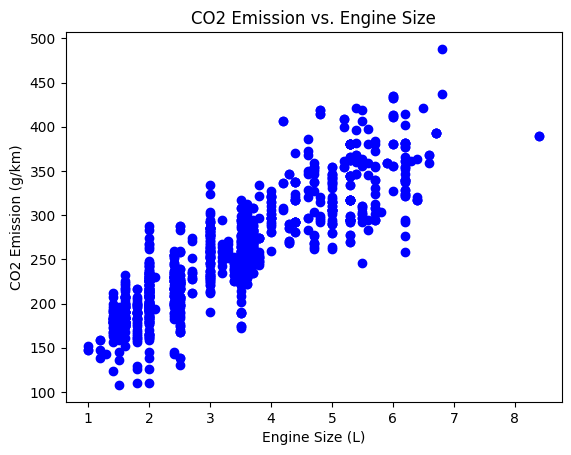

In [36]:
plt.scatter(cdf["ENGINESIZE"], cdf["CO2EMISSIONS"],  color='blue')
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emission (g/km)")
plt.title("CO2 Emission vs. Engine Size")
plt.show()

> **Observation:** 
> * The relationship between `ENGINESIZE` and `CO2EMISSIONS` is also quite linear, but it's "noisier" and less tightly correlated than the fuel consumption plot. It's still a good candidate for our model.



---

## 3. Data Preparation for Modeling

For our first model, we will use `ENGINESIZE` to predict `CO2EMISSIONS`.

First, we need to separate our data into the **feature matrix (X)** and the **target vector (y)**. It's a convention in scikit-learn for `X` to be a 2D array (or DataFrame) and `y` to be a 1D array.

In [12]:
# Scikit-learn expects X to be a 2D array of shape (n_samples, n_features)
X = cdf[["ENGINESIZE"]].values # Note the double brackets

# y can be a 1D array
y = cdf["CO2EMISSIONS"].values # Note the single brackets

### Create Train and Test Datasets

This is a critical step in machine learning. We need to split our data into two parts:
1. **Training Set:** The majority of the data, which we'll use to teach our model.
2. **Testing Set:** A smaller portion of data that the model has *never seen before*. We'll use this to get an unbiased evaluation of how well our model generalizes to new, unseen data.

We'll use an 80/20 split. Setting a `random_state` ensures that we get the exact same "random" split every time we run the code, which makes our results reproducible.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


---

## 4. Build and Train the Model

Now for the exciting part! We'll use scikit-learn's `LinearRegression` object to create and train our model.

In [18]:
from sklearn import linear_model

# 1. Create an instance of the LinearRegression model
regressor = linear_model.LinearRegression()

# 2. Train the model using our training data.
regressor.fit(X_train, y_train)

# 3. Let's look at the parameters the model learned.
print(f"Coefficient (slope): {regressor.coef_[0]:.2f}")
print(f"Intercept: {regressor.intercept_:.2f}")

Coefficient (slope): 38.99
Intercept: 126.29


> **Interpretation:** 
> * The model has learned the equation: `CO2EMISSIONS = 126.29 + 38.99 * ENGINESIZE`. This means that for every one-liter increase in engine size, the model predicts a ~39 g/km increase in CO2 emissions.

### Visualize the Model Fit
Let's plot the "best-fit" line that our model has found over the training data:

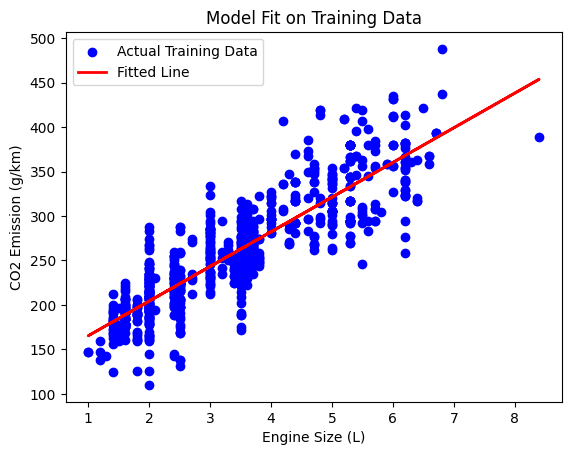

In [20]:
plt.scatter(X_train, y_train, color="blue", label="Actual Training Data")
plt.plot(X_train, regressor.predict(X_train), color="red", linewidth=2, label="Fitted Line")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emission (g/km)")
plt.title("Model Fit on Training Data")
plt.legend()
plt.show()


---

## 5. Evaluate the Model

Our model looks good on the training data, but how does it perform on data it's never seen before? This is the true test of its predictive power.

We'll use a few standard regression evaluation metrics:
* **Mean Absolute Error (MAE):** The average absolute difference between the predicted and actual values. It's easy to interpret: "On average, our predictions are off by X units."
* **Root Mean Squared Error (RMSE):** The square root of the Mean Squared Error. This brings the metric back to the original units of the target variable, making it more interpretable than MSE.
* **R-squared (R²):** A popular metric that represents the proportion of the variance in the target variable that is predictable from the feature(s). An R² of 1.0 is a perfect fit.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the trained model to make predictions on the test set 
y_pred = regressor.predict(X_test)

# Now, compare the predictions (y_pred) with the true values (y_test)
print("Evaluation on Test Set:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}") 
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R-squared (R²): {r2_score(y_test, y_pred):.2f}")

Evaluation on Test Set:
Mean Absolute Error: 24.10
Root Mean Squared Error: 31.40
R-squared (R²): 0.76


> **Interpretation:**  
> *   On average, our model's predictions are off by about 24.10 g/km (MAE).
> *   The R² score of 0.76 tells us that our model explains about 76% of the variability in CO2 emissions, which is quite good for a simple model with only one feature!

We can also plot the regression model result over the *test data* instead of the training data, so we can visually evaluate whether the result is good.

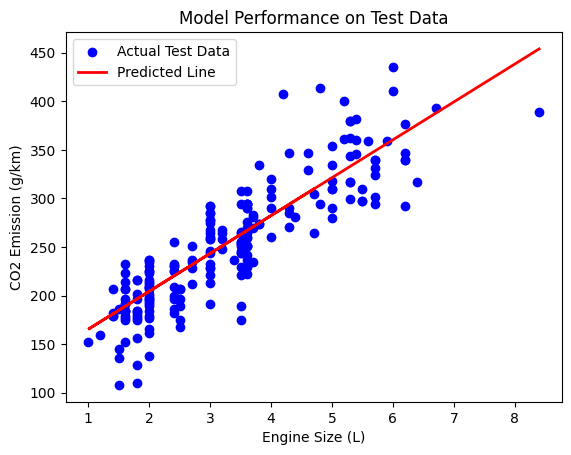

In [37]:
plt.scatter(X_test, y_test,  color='blue', label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Line')
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emission (g/km)")
plt.title("Model Performance on Test Data")
plt.legend()
plt.show()



---

## 6. Try Another Model with Another Predictor
Our model worked reasonably well with `ENGINESIZE` as the predictor. Now let's see if we can do better by using a different feature: `FUELCONSUMPTION_COMB`:

In [38]:
# Create a new feature matrix (the target vector is the same as before)
X_fuel = cdf[["FUELCONSUMPTION_COMB"]].values

# Split the data
X_train_fuel, X_test_fuel, y_train_fuel, y_test_fuel = train_test_split(X_fuel, y, test_size=0.2, random_state=42)

# Create a new regressor object
regr_fuel = linear_model.LinearRegression()

# Fit it to new training data
regr_fuel.fit(X_train_fuel, y_train_fuel)

# Make predictions
y_pred_fuel = regr_fuel.predict(X_test_fuel)

# Calculate and print the evaluation metrics for the new model
print("Evaluation for Fuel Consumption Model:")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_fuel, y_pred_fuel):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_fuel, y_pred_fuel)):.2f}")
print(f"R-squared (R²): {r2_score(y_test_fuel, y_pred_fuel):.2f}")

Evaluation for Fuel Consumption Model:
Mean Absolute Error (MAE): 20.44
Root Mean Squared Error (RMSE): 28.24
R-squared (R²): 0.81


> **Conclusion:**  
> As we suspected from our initial EDA, the model using `FUELCONSUMPTION_COMB` is superior to the one using `ENGINESIZE`. It has lower errors (MAE and RMSE) and a higher R² score (0.80 vs. 0.76), meaning it explains more of the variance in CO2 emissions. This demonstrates the importance of feature selection in building effective models!

---

**Next:** [Multiple Linear Regression](./04_multiple_linear_regression.md)